**Import Libraries**

In [25]:
# Import core libraries
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import LabelEncoder

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

# Evaluation
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

**Load Dataset**

In [26]:
# Load datasets
train = pd.read_csv("train.csv")
test = pd.read_csv("test.csv")

print("Train Shape:", train.shape)
print("Test Shape:", test.shape)

Train Shape: (891, 12)
Test Shape: (418, 11)


**EDA : Exploratory Data Analysis**

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB
None
       PassengerId    Survived      Pclass         Age       SibSp  \
count   891.000000  891.000000  891.000000  714.000000  891.000000   
mean    446.000000    0.383838    2.308642   29.699118    0.523008   
std     257.353842    0.48659

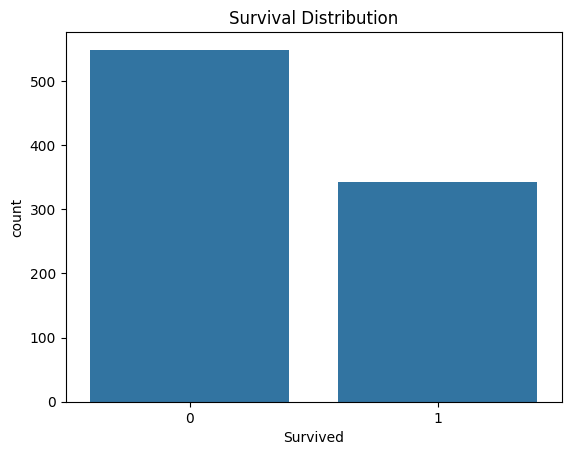

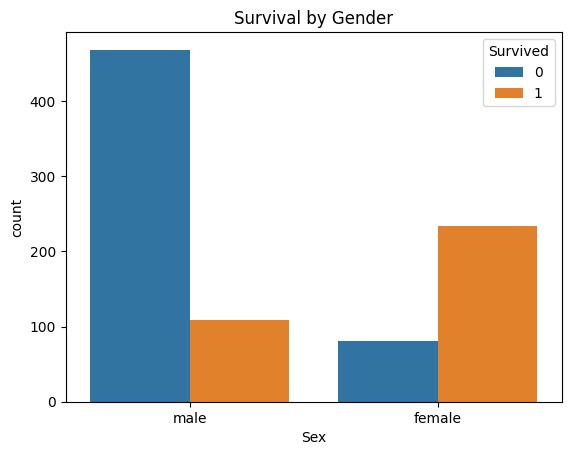

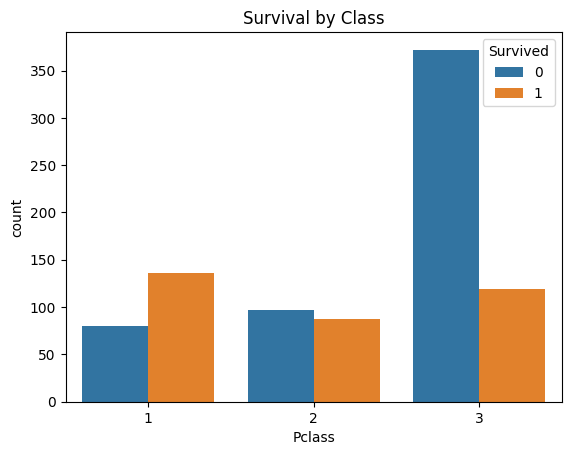

In [27]:
# EDA - Understanding Data
print(train.info())
print(train.describe())

# Survival distribution
sns.countplot(x='Survived', data=train)
plt.title("Survival Distribution")
plt.show()

# Survival by Gender
sns.countplot(x='Sex', hue='Survived', data=train)
plt.title("Survival by Gender")
plt.show()

# Survival by Class
sns.countplot(x='Pclass', hue='Survived', data=train)
plt.title("Survival by Class")
plt.show()

**Data Cleaning**

In [28]:
# Handle missing values
for df in [train, test]:
    df['Age'] = df['Age'].fillna(df['Age'].median())
    df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])
    df['Fare'] = df['Fare'].fillna(df['Fare'].median())

# Drop unnecessary columns
train.drop(['Cabin', 'Name', 'Ticket'], axis=1, inplace=True)
test.drop(['Cabin', 'Name', 'Ticket'], axis=1, inplace=True)

**Encoding**

In [29]:
# Encode categorical variables
le = LabelEncoder()

for df in [train, test]:
    df['Sex'] = le.fit_transform(df['Sex'])
    df['Embarked'] = le.fit_transform(df['Embarked'])

**Feature Engineering**

In [30]:
# Feature Engineering
for df in [train, test]:
    df['FamilySize'] = df['SibSp'] + df['Parch'] + 1
    df['IsAlone'] = (df['FamilySize'] == 1).astype(int)

**Feature Selection**

In [31]:
# Features & target
X = train.drop(['Survived'], axis=1)
y = train['Survived']

# Store PassengerId for submission
test_ids = test['PassengerId']

# Drop ID columns
X = X.drop('PassengerId', axis=1)
X_test = test.drop('PassengerId', axis=1)

**Train-Test Split**

In [32]:
# Split data
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42
)

**Model Comparison**

In [33]:
# Define models
models = {
    "Logistic Regression": LogisticRegression(max_iter=200),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(random_state=42),
    "Gradient Boosting": GradientBoostingClassifier()
}

# Train and evaluate
print("Model Comparison:\n")
for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_val)
    acc = accuracy_score(y_val, preds)
    print(f"{name}: {acc:.4f}")

Model Comparison:

Logistic Regression: 0.8045
Decision Tree: 0.7654


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Random Forest: 0.8156
Gradient Boosting: 0.8045


**Best Model Selection Explanation**

In [34]:
# Selecting best model
print("\nRandom Forest selected as final model due to highest validation accuracy.")


Random Forest selected as final model due to highest validation accuracy.


**Final Model (Random Forest)**

In [35]:
# Train final model
final_model = RandomForestClassifier(n_estimators=100, random_state=42)
final_model.fit(X_train, y_train)

# Validation prediction
y_pred = final_model.predict(X_val)

# Accuracy
print("\nFinal Model Accuracy:", accuracy_score(y_val, y_pred))


Final Model Accuracy: 0.8156424581005587


**Evaluation Metrics**

In [36]:
# Confusion Matrix
print("\nConfusion Matrix:")
print(confusion_matrix(y_val, y_pred))

# Classification Report
print("\nClassification Report:")
print(classification_report(y_val, y_pred))


Confusion Matrix:
[[90 15]
 [18 56]]

Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.86      0.85       105
           1       0.79      0.76      0.77        74

    accuracy                           0.82       179
   macro avg       0.81      0.81      0.81       179
weighted avg       0.81      0.82      0.82       179



**Insights**

In [37]:
# Key Insights
print("\nKey Insights:")
print("- Gender and Pclass are strong predictors of survival")
print("- Random Forest performs best among tested models")
print("- Feature importance shows which variables influence predictions most")


Key Insights:
- Gender and Pclass are strong predictors of survival
- Random Forest performs best among tested models
- Feature importance shows which variables influence predictions most


**Feature Importance**

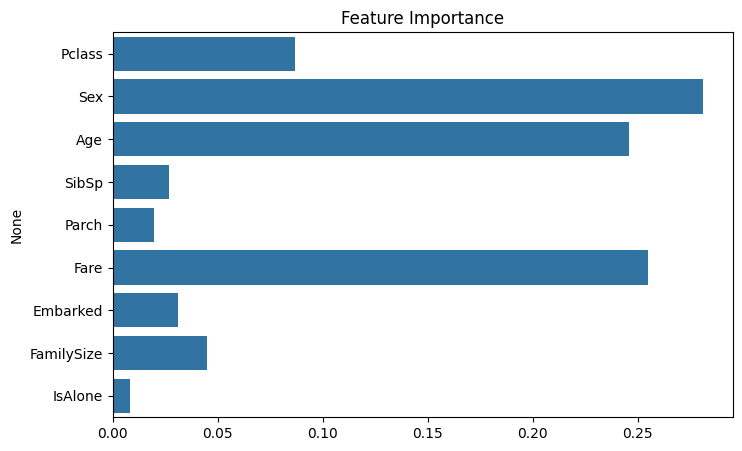

In [38]:
# Feature importance
importances = final_model.feature_importances_
features = X.columns

plt.figure(figsize=(8,5))
sns.barplot(x=importances, y=features)
plt.title("Feature Importance")
plt.show()

**Hyperparameter Tuning**

In [39]:
# GridSearchCV
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5, 7]
}

grid = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid,
    cv=5,
    scoring='accuracy'
)

grid.fit(X_train, y_train)

print("\nBest Parameters:", grid.best_params_)
print("Best Score:", grid.best_score_)


Best Parameters: {'max_depth': 5, 'n_estimators': 100}
Best Score: 0.832798187727765


**Final Prediction**

In [40]:
# Use best model
best_model = grid.best_estimator_

predictions = best_model.predict(X_test)

# Submission file
submission = pd.DataFrame({
    "PassengerId": test_ids,
    "Survived": predictions
})

submission.to_csv("submission.csv", index=False)

print("✅ Submission file created!")

✅ Submission file created!


**Conclusion**

In [41]:
# Conclusion
print("\nConclusion:")
print("This project demonstrates an end-to-end ML workflow including preprocessing, model comparison, evaluation, and prediction.")
print("Random Forest with tuned parameters achieved the best performance.")


Conclusion:
This project demonstrates an end-to-end ML workflow including preprocessing, model comparison, evaluation, and prediction.
Random Forest with tuned parameters achieved the best performance.
